In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import PIL
import numpy as np
from instaflow.pipeline_drag import RectifiedFlowStateMachine
from utils import MaskPainter, show_images_in_row, set_seed
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pipe = RectifiedFlowStateMachine.from_pretrained(
    "XCLiu/2_rectified_flow_from_sd_1_5", 
    torch_dtype=torch.bfloat16, 
    device_map=DEVICE
)
pipe.safety_checker = None

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Data/yiming.chen/envs/py311/lib/python3.11/site-packages/diffusers/loaders/lora_pipeline.py:5501: FutureWarning: `LoraLoaderMixin` is deprecated and will be removed in version 1.0.0. LoraLoaderMixin is deprecated and this will be removed in a future version. Please use `StableDiffusionLoraLoaderMixin`, instead.
  deprecate("LoraLoaderMixin", "1.0.0", deprecation_message)


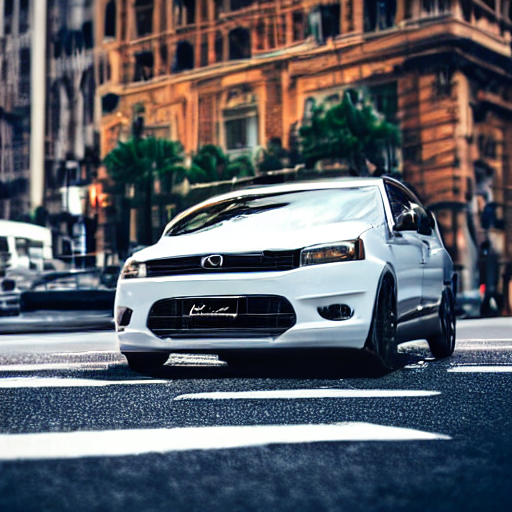

In [3]:
set_seed(512)
state_fg = pipe.prepare_state(
    prompt="A car in the city, high quality, detailed",
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=3,
    capture_all_intermediate_features=True,
)

def example_callback(i, t, dt, latent, features, v_pred):
    next_latent = latent + dt * v_pred
    return next_latent

state_fg = pipe.infer_from_state(state_fg, until=50, callback=example_callback)
img_fg = pipe.decode_latents(state_fg.latent)[0][0]
img_fg

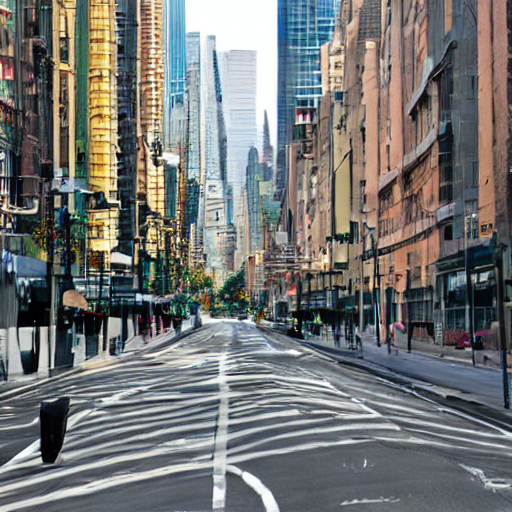

In [4]:
set_seed(25886)

state_bg = pipe.prepare_state(
    prompt="A city road, high quality, detailed",
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=1.5,
    capture_all_intermediate_features=False,
)

def example_callback(i, t, dt, latent, features, v_pred):
    next_latent = latent + dt * v_pred
    return next_latent

state_bg = pipe.infer_from_state(state_bg, until=50, callback=example_callback)
img_bg = pipe.decode_latents(state_bg.latent)[0][0]
img_bg

In [5]:
painter = MaskPainter(img_fg, brush_radius=20, fill_style="rgba(255, 255, 255, 0.8)")
painter.show()

Canvas(height=512, width=512)

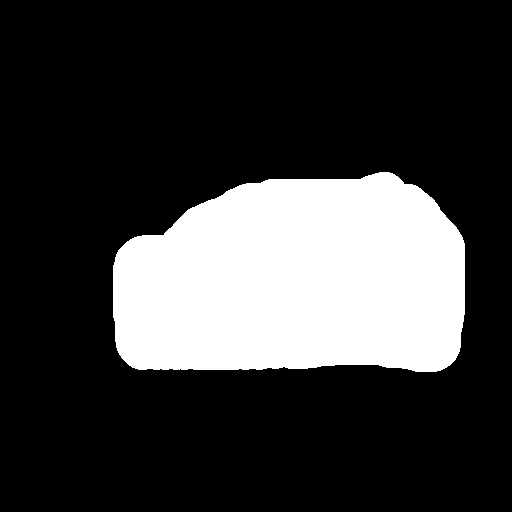

In [8]:
# show mask
mask = painter.get_mask()
mask_img = PIL.Image.fromarray((mask * 255).astype(np.uint8))
mask_img

Mask tensor shape: torch.Size([1, 1, 512, 512]), dtype: torch.bfloat16
Method 1: Optimizing latent from step 20 to 25...
Starting blending optimization...
timestep 20...timestep 21...timestep 22...timestep 23...timestep 24...

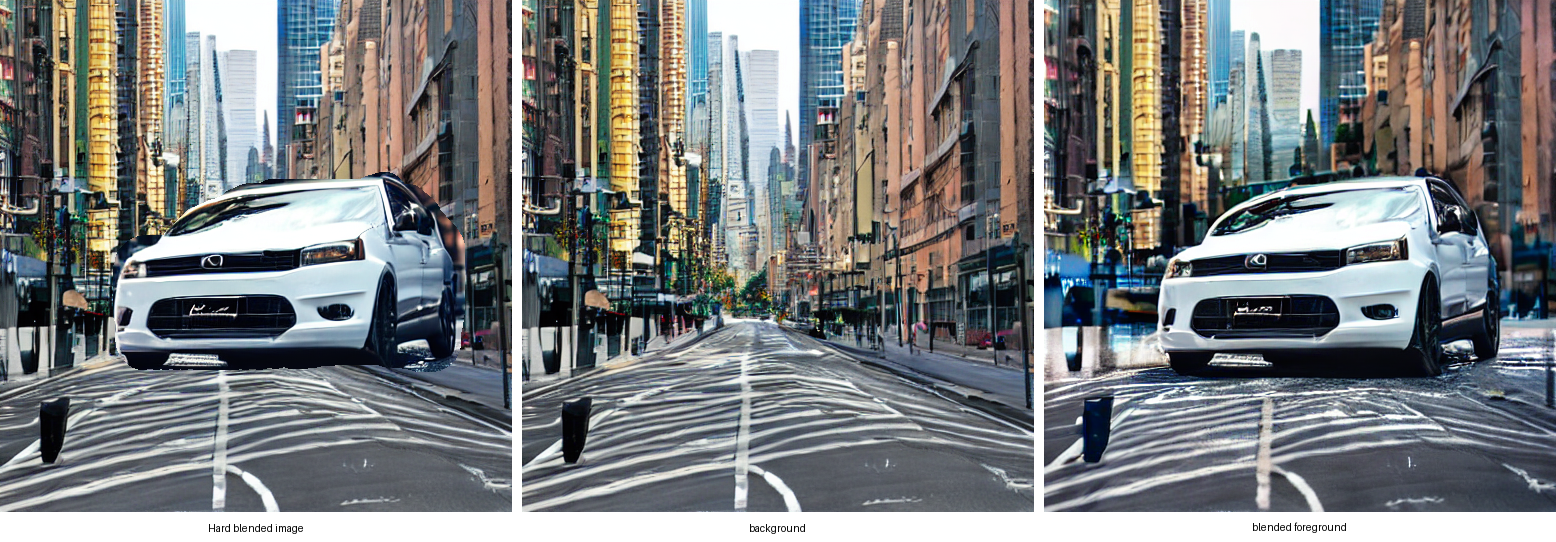

In [9]:
from instaflow.blend_transfer import BlendConfig, blend_with_fg_features

mask = painter.get_mask() # 0-1 numpy array dtype uint8
mask_tensor = torch.from_numpy(mask).to(device=state_bg.device, dtype=state_bg.latent.dtype)
if mask_tensor.ndim == 2:
    mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
print(f"Mask tensor shape: {mask_tensor.shape}, dtype: {mask_tensor.dtype}")

########################### HARD BLENDING #################################
# Simple blending: mask * foreground + (1 - mask) * background
fg_array = np.array(img_fg).astype(np.float32) / 255.0
bg_array = np.array(img_bg).astype(np.float32) / 255.0
mask_array = mask[:, :, np.newaxis]
blended_array = mask_array * fg_array + (1.0 - mask_array) * bg_array
blended_img = PIL.Image.fromarray((blended_array * 255).astype(np.uint8))
blended_img

############################ SOFT BLENDING ################################

# Configs
config = BlendConfig(
    blend_start_step=20,
    blend_end_step=25,
    optim_steps_per_inference=10,
    lr=0.1,
    lamfg=0.01, # fg guidance scale
    lambg=0.001 # bg guidance scale
)

# Clone bg state as reference and regenerate with features
print(f"Method 1: Optimizing latent from step {config.blend_start_step} to {config.blend_end_step}...")
state_bg_ref = state_bg.clone()
state_bg_ref.capture_all_intermediate_features = True
state_bg_ref.intermediate_latents = []
state_bg_ref.reset()
state_bg_ref = pipe.infer_from_state(state_bg_ref, until=50)

print("Starting blending optimization...")
state_bg.reset()
state_bg = pipe.infer_from_state(state_bg, until=50,
    callback = blend_with_fg_features(pipe, state_fg, state_bg_ref, mask_tensor, config)
)
torch.cuda.empty_cache()
img_method1 = pipe.decode_latents(state_bg.latent)[0][0]

######################## ORIGINAL IMAGE #####################################
state_bg.reset()
state_bg = pipe.infer_from_state(state_bg, until=50, callback=None)
torch.cuda.empty_cache()
orig_img = pipe.decode_latents(state_bg.latent)[0][0]


################################ SHOW #######################################
show_images_in_row(
    [blended_img, orig_img, img_method1 ],
    ["Hard blended image", "background", "blended foreground"]
)

## Depth-aware editing

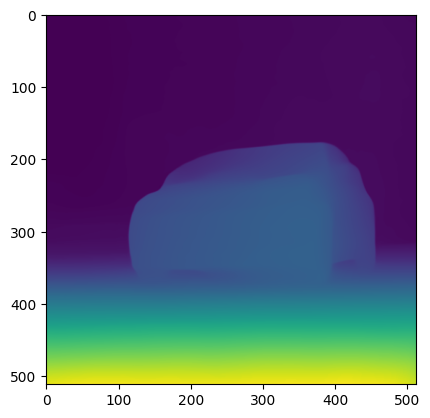

In [14]:
from depth_anything.dpt import DepthAnything
import matplotlib.pyplot as plt
from utils.depth_estimation import estimate_depth_from_image
ENCODER = 'vitl' # choices=['vits', 'vitb', 'vitl']
depth_anything = DepthAnything.from_pretrained(f'LiheYoung/depth_anything_{ENCODER}14').to(DEVICE).eval()
depth_map = estimate_depth_from_image(img_fg, DEVICE, depth_model=depth_anything)
plt.imshow(depth_map)
plt.show()

In [68]:
from utils.vis_utils import DepthPoseEditor, euler_to_R

In [69]:
editor = DepthPoseEditor(img_fg, depth=depth_map)
editor.show()

In [59]:
editor_output = editor.get_output()
print(editor_output)

{'source': {'x': -0.24, 'y': 0.1299999999999999, 'z': 0.88, 'roll': 1.3439035240356338, 'pitch': 0.15707963267948966, 'yaw': 0.017453292519943295}, 'target': {'x': 0.20999999999999996, 'y': 0.20999999999999996, 'z': 1.0799999999999998, 'roll': 1.413716694115407, 'pitch': -0.5061454830783556, 'yaw': 0.017453292519943295}, 'relative': {'translation': {'x': 0.44999999999999996, 'y': 0.08000000000000007, 'z': 0.19999999999999984}, 'rotation': {'type': 'euler', 'roll': 0.06981317007977306, 'pitch': -0.6632251157578453, 'yaw': 0.0}}}


In [60]:
import numpy as np

def pose_to_SE3(tx, ty, tz, roll, pitch, yaw):
    R = euler_to_R(roll, pitch, yaw)
    T = np.eye(4, dtype=np.float32)
    T[:3, :3] = R
    T[:3, 3] = [tx, ty, tz]
    return T

def apply_SE3(P, T):
    """
    Apply SE(3) transform T to 3D points P.

    Args:
        P: (N, 4) homogeneous 3D points [x, y, z, 1]
        T: (4, 4) SE(3) matrix

    Returns:
        P_new: (N, 4) transformed points
    """
    return (T @ P.T).T

def depth_to_points(depth, mask, K):
    H, W = depth.shape
    ys, xs = np.where(mask)

    z = depth[ys, xs]
    fx, fy = K[0,0], K[1,1]
    cx, cy = K[0,2], K[1,2]

    x = (xs - cx) * z / fx
    y = (ys - cy) * z / fy

    P = np.stack([x, y, z, np.ones_like(z)], axis=1)  # N×4
    return P, xs, ys

def points_to_depth(P, xs, ys, depth_shape):
    H, W = depth_shape
    new_depth = np.zeros((H, W), dtype=np.float32)

    z = P[:, 2]
    valid = z > 1e-6

    xs = xs[valid]
    ys = ys[valid]
    z  = z[valid]

    # z-buffer：取最近的
    for x, y, zi in zip(xs, ys, z):
        if new_depth[y, x] == 0 or zi < new_depth[y, x]:
            new_depth[y, x] = zi

    return new_depth

In [62]:
# 1. 构造 SE(3)
rel = editor_output["relative"]
T = pose_to_SE3(
    rel["translation"]["x"],
    rel["translation"]["y"],
    rel["translation"]["z"],
    rel["rotation"]["roll"],
    rel["rotation"]["pitch"],
    rel["rotation"]["yaw"],
)
H, W = depth_map.shape
f = max(H, W)          # 或者 0.8 * max(H, W)

K = np.array([
    [f, 0, W / 2],
    [0, f, H / 2],
    [0, 0, 1]
], dtype=np.float32)
# 2. depth -> 3D
P, xs, ys = depth_to_points(depth_map, mask, K)

# 3. apply transform
P_new = apply_SE3(P, T)

# 4. project back to depth
new_depth_map = points_to_depth(P_new, xs, ys, depth_map.shape)

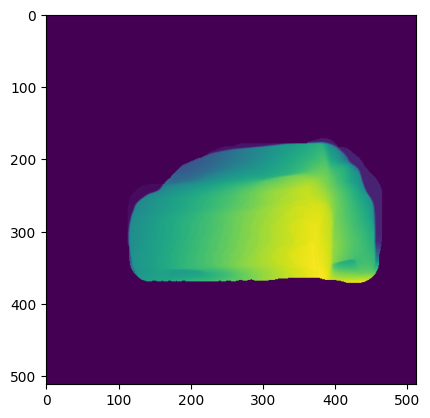

In [63]:
plt.imshow(new_depth_map)